### Circle Version
If I let the edge parameter form a circle rather than a square, then I think I can bring the circle closer to the crystal without changing the physics. To explain, imagine a concentric set of squares. If particles pass through the outside square from the outside in a uniform matter and take random walks then they won't pass through the inner square in a uniformly distributed manner. However, for concentric circles, if the particles come through the outer circle from the outside in a uniform distribution around the circles circumference and take random walks, then they will pass through the inner circle in a uniformly distributed manner as well. Thus, I think if I change the edge to a circle, then I can bring it much closer to the crystal, improving the efficiency.


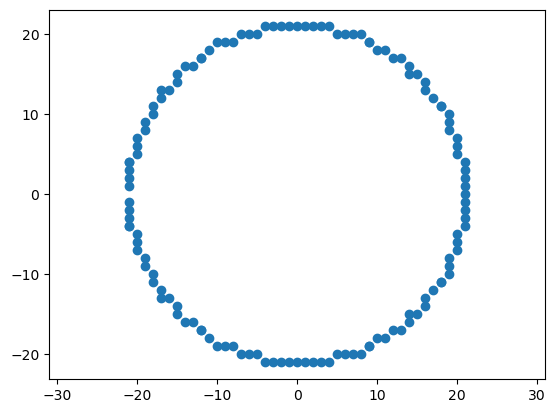

In [1]:
import numpy as np
import matplotlib.pyplot as plt

radius = 21



def generate_space(radius):
    num_edge_blocks = int(2 * np.pi * radius)                                                               # num edge blocks is the integer value of circumerence
    theta = np.linspace(0, 2 * np.pi, num_edge_blocks, endpoint=False)                                      # generates num_edge_blocks angles evenly spaced around the circle
    x, y = np.round(radius * np.cos(theta)).astype(int), np.round(radius * np.sin(theta)).astype(int)       # finds the x and y positions of the points on the circle
    return x, y


x, y = generate_space(radius)
circle_set = np.unique(np.column_stack((x, y)), axis=0)         # pairs x and y defines the circle (np.unique removes any duplicates due to rounding)

plt.plot(x, y, 'o')
plt.axis('equal')
plt.show()

Notes to self: Still use the square space but now you don't have to impose L >> R since the particles spawn on the circle so I can bring this closer. Don't bring it closer than R though.
You want to compare the capacity dimension for different conditions for resizing_square. Then, you want to push the conditions as tight as possible without changing the capacity dimensions. Ensure circle is contained in square.

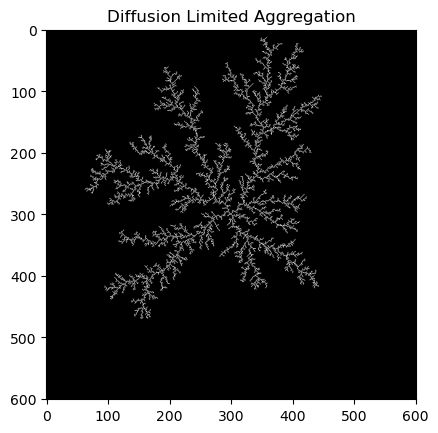

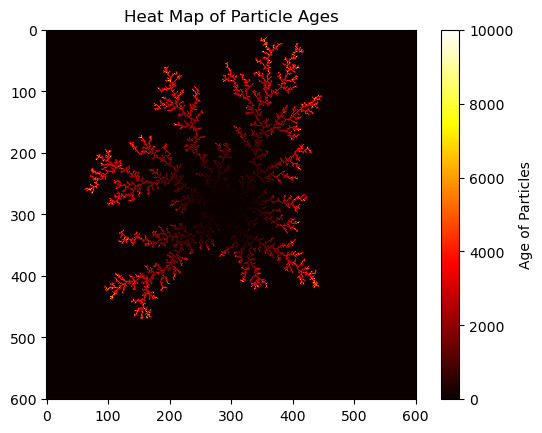

In [ ]:
##################################################################################
# RUN LOG:
#
# X1)  N=1000, start length = 51, resizing_square set to: length < 3r_max, resizing_circle set to: radius < r_max + 10
#     Runtime: 1 min and 15.5 s.
# X2) N=1000, start length = 51, resizing_square set to: length < 2(r_max+2) then length = length + 4, resizing_circle set to: radius < r_max + 10
#    Runtime: 12.5 s
# X3) N=1000, start length = 51, resizing_square set to: length < 2(r_max+4) then length = length + 8, resizing_circle set to: radius < r_max + 10
#    Runtime: 48.4 s
# X4) N=1000, start length = 51, resizing_square set to: length < 2(r_max+5) then length = length + 10, resizing_circle set to: radius < r_max + 10
#    Runtime: 56.1 s
#
#   Need to make sure the circle is contained in the square, new runs. 
#
#   1) N=1000, start length = 51, resizing_square set to: if length < 2r_max + 20 then length = length + 20, resizing_circle set to: radius < r_max + 10
#   Runtime: 1 min and 48.1 s.
#
#   2) N=2000, start length = 51, resizing_square set to: if length < 2r_max + 20 then length = length + 20, resizing_circle set to: radius < r_max + 10
#   Runtime: 4 min and 17.8 s.
#
#   3) N=2000, start length = 51, resizing_square set to: if length < 2r_max + 20 then length = length + 20, resizing_circle set to: radius < r_max + 10
#   Runtime: 2 min and 54.4 s.
#
#   4) N=2000, start length = 51, resizing_square set to: if length < 2r_max + 20 then length = length + 10, resizing_circle set to: radius < r_max + 10
#   Runtime: 3 min and 4.4 s.
#
#   5) N=10000, start length = 51, resizing_square set to: if length < 2r_max + 20 then length = length + 10, resizing_circle set to: radius < r_max + 10
#   Runtime: 59 min and 59.2 s
#
#
#
#
#
###################################################################################



radius = 21
# copy and pasting the algorithm then replacing square parameter with the circle.

##########################################################################################################################################

length = 51                                               # added length variable so I can change it easier (must be odd to have a center seed)
heat = np.zeros((length, length))                         # tracks age of particles


                                                          # v changed 100 to 101 so the seed is actually centered
space = np.zeros((length, length), dtype=bool)            # boolean array to represent discrete 2D space (102x102 blocks): True for occupied block, false for empty block
space[length//2, length//2] = True                        # puts the seed in the middle


stickiness = 1                                            # factor value between (0 to 1). The chance it has of sticking to the seed

seed = True


def resizing_circle():                                                  # spawn points         
    ##############################################
    # Adaptive resizing
    global length, space, heat, radius, circle_set                      # I should probably pass these later but rn Im just testing stuff
    

    crystal_indices = np.argwhere(space)                                # find the indices in space where the crystal is (true)
    dx = crystal_indices[:, 0] - length//2                              # finds the x components of r's
    dy = crystal_indices[:, 1] - length//2                              # finds the y components of r's
    r_max = int(np.max(np.sqrt(dx**2 + dy**2))) + 1                     # finds the max radius r_max

    if radius < r_max + 10:
        new_radius = r_max + 10
        new_circle_set = np.unique(np.column_stack(generate_space(new_radius)), axis=0)     
        radius = new_radius
        circle_set = new_circle_set    

def resizing_square():                                                  # boundaries
    ##############################################
    # Adaptive resizing
    global length, space, heat                                          # I should probably pass these later but rn Im just testing stuff
    
    r_max = np.max(np.abs(np.argwhere(space) - length//2)) + 1          # max distance from the center seed
    if length < (2 * r_max) + 20:                                              # condition to adjust length
        new_length = length + 10
        if new_length % 2 == 0:                                         # ensures new length is odd so seed can remain centered
            new_length += 1

        new_space = np.zeros((new_length, new_length), dtype=bool)      # adjusts space to new length dimensions
        new_heat = np.zeros((new_length, new_length))                   # adjusts heat to new length dimensions

        shift = (new_length - length) // 2                              # shift such that the space expands outwards from center

        crystal_indices = np.argwhere(space)                            # ^ adjusts space such that it adds space outwards from center
        for x, y in crystal_indices:
            new_space[x + shift, y + shift] = True
            new_heat[x + shift, y + shift] = heat[x, y]
        
        length = new_length                                             # updates length
        space = new_space                                               # updates space
        heat = new_heat                                                 # updates heat

    ##############################################


def random_walk(i):
    global length, space, heat, radius, circle_set                                          # I should probably pass these later but rn Im just testing stuff

    resizing_square()
    resizing_circle()

    x, y = circle_set[np.random.randint(len(circle_set))]                           # chooses random point on circle to spawn particle
    x += length // 2                                                                # aligns circle to be centered at the seed
    y += length // 2                                                                # aligns circle to be centered at the seed  


    while (True):                           # Loop until the particle sticks to seed
        # RANDOM WALK ALGORITHM
        direction = np.random.choice(['up', 'down', 'left', 'right'])
        if direction == 'up':
            y = (y + 1) % length
        elif direction == 'down':
            y = (y - 1) % length
        elif direction == 'left':
            x = (x - 1) % length
        elif direction == 'right':
            x = (x + 1) % length
        
        # Check if particle is next to the seed (3x3 neighborhood)
        if (space[x-1:x+2, y-1:y+2].any()):                                 # Starts at x-1 and goes up to but not including x+2.
            # Chance of sticking to the seed is the stickiness factor
            if np.random.rand() < stickiness:
                space[x, y] = seed
                heat[x, y] = i + 1                                          # tracks the age of the particle that sticks to the seed
                break                                                       # moved break inside the if so it only breaks if the particle sticks


# DLA Simulation

x, y = generate_space(radius)
circle_set = np.unique(np.column_stack((x, y)), axis=0)

N = 10000 # number of particles
for i in range(N):
    random_walk(i)

# image plotting from matplotlib plots the space array
plt.imshow(space, cmap='gray')
plt.title('Diffusion Limited Aggregation')
plt.show()

# plot heat map
plt.imshow(heat, cmap='hot')
plt.title('Heat Map of Particle Ages')
plt.colorbar(label='Age of Particles')
plt.show()